# Compressible Euler Equations

## Generate Data & Fit Basis

#### Imports & Config

In [74]:
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

%matplotlib inline

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1
import random

In [75]:
training_span = (0, 0.08)
num_samples = 200
noiselevel = .01
num_regression_points = 250
numPODmodes = 6
num_pulls = 200
time_domain_test = np.linspace(0, training_span[-1], num_regression_points)
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)



normalization = 1e-3

In [76]:
sampler = step1.trajectory(
    training_span,
    num_samples,
    noiselevel,
)
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, noiselevel)

time_domain_eval_prediction = np.linspace(0, time_domain[-1], int(num_regression_points/training_span[-1]*time_domain[-1]))

print(true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape)

generating training data...done in 0.91 s.
generating training data...done in 0.86 s.
(600, 401) (200,) (600, 200)


### Fit Basis

In [77]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 6 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (600, 200)
(600, 200) (600, 200)
(6, 401)
done in 0.05 s.


## Run Model GP Model and Visualize Results

### Bayesian GP

#### Define and Run Model

Starting SVI optimization...
Iteration 0: loss = 7316.2603
Iteration 100: loss = 2805.4307
Iteration 200: loss = 1504.3434
Iteration 300: loss = 1127.3129
Iteration 400: loss = 840.0737
Iteration 500: loss = 738.5877
Iteration 600: loss = 551.3008
Iteration 700: loss = 247.0682
Iteration 800: loss = 21.1239
Iteration 900: loss = -201.9106
Iteration 1000: loss = -443.3562
Iteration 1100: loss = -755.0886
Iteration 1200: loss = -818.4407
Iteration 1300: loss = -997.3820
Iteration 1400: loss = -1082.2385
Iteration 1500: loss = -1377.3943
Iteration 1600: loss = -1394.4468
Iteration 1700: loss = -1576.1792
Iteration 1800: loss = -1672.9109
Iteration 1900: loss = -1663.8286
Iteration 2000: loss = -1761.3400
Iteration 2100: loss = -1720.7164
Iteration 2200: loss = -1842.5745
Iteration 2300: loss = -1902.5854
Iteration 2400: loss = -1927.6410
Iteration 2500: loss = -1912.2061
Iteration 2600: loss = -1914.1365
Iteration 2700: loss = -2003.9978
Iteration 2800: loss = -1918.3994
Iteration 2900: l

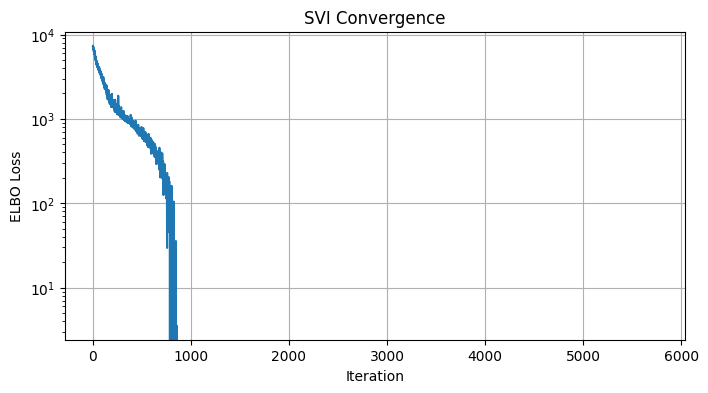

In [78]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        chi: float = 1e-6, 
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[0]
    numPODmodes = qhat.shape[0]
    
    # Get time scale
    time_range = time.max() - time.min()
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # Analyze data scale
        data_std = jnp.std(qhat[i])
        
        # For oscillatory data, we need small lengthscales
        # Start with a prior centered at ~1/20th of the time range
        lengthscale = numpyro.sample(f"lengthscale{i}", 
                                     dist.LogNormal(jnp.log(time_range/20), 1.0))
        Ls.append(lengthscale)
        
        # Variance based on data variance
        variance = numpyro.sample(f"variance{i}", 
                                 dist.LogNormal(jnp.log(data_std**2), 0.5))
        Vars.append(variance)
        
        # Small noise since data looks clean
        noise = numpyro.sample(f"noise{i}", 
                              dist.LogNormal(-8.0, 1.0))  # Very small noise
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add tiny regularization for numerical stability
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])

# Create autoguide
guide = autoguide.AutoLowRankMultivariateNormal(model, rank=30)

# Setup optimizer - start with higher learning rate and decay
optimizer = Adam(step_size=0.01)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop with patience
num_iterations = 20000  # More iterations
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Rest of your code remains the same...
# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")


# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

### Visualize

#### GP Predictions

Number of samples: 250


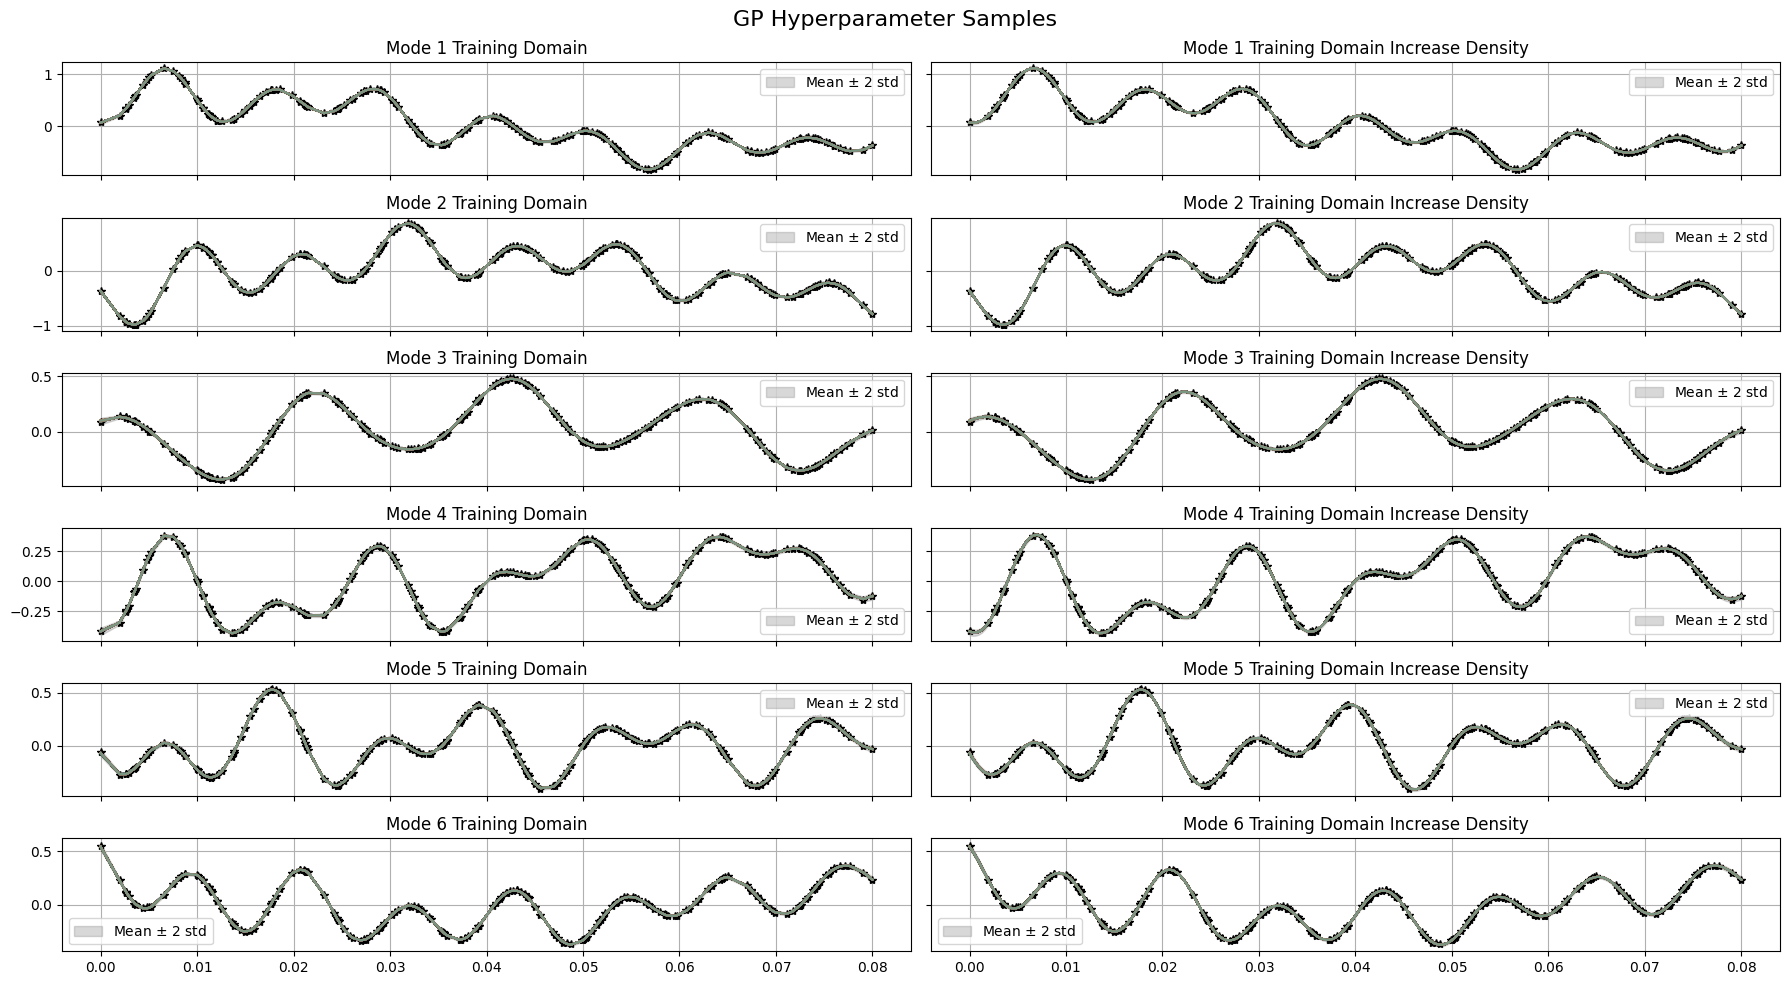

(200, 200) (200,)
(200, 200) (200,)
(200, 200) (200,)
(200, 200) (200,)
(200, 200) (200,)
(200, 200) (200,)


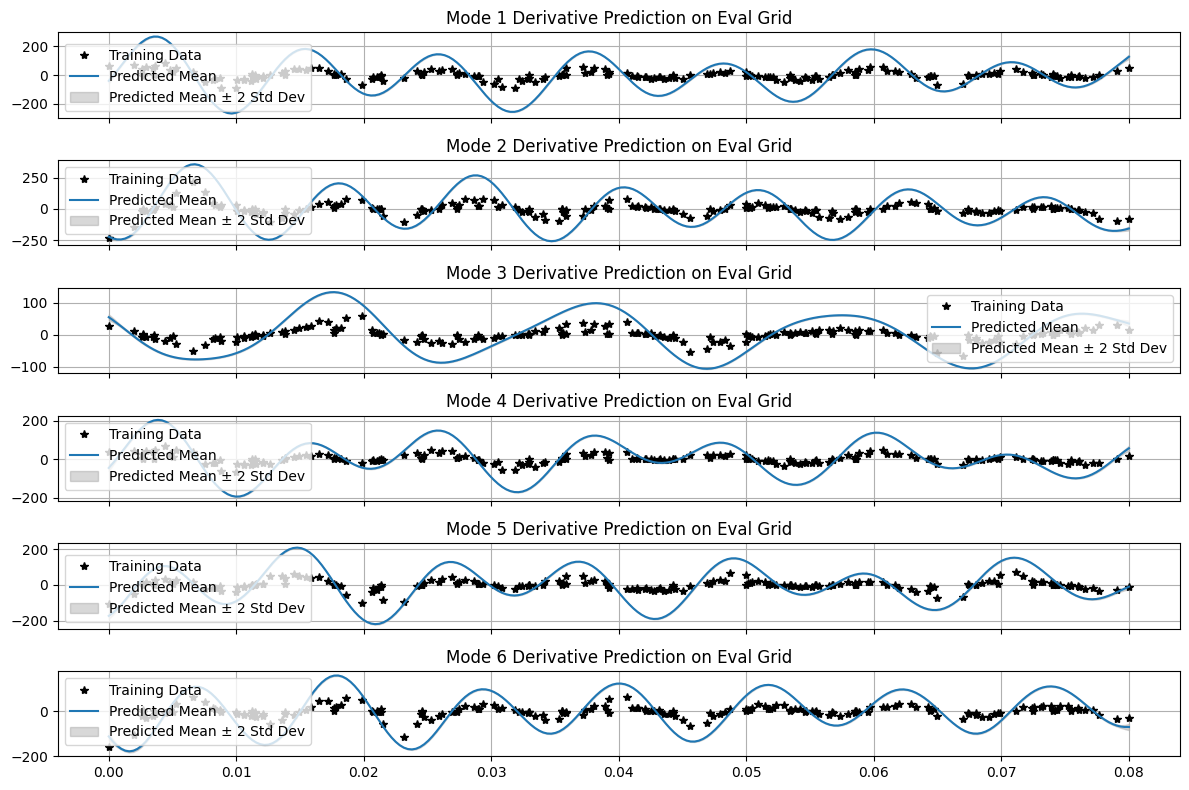

In [79]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )
plotter.gp_plot_state(
    lengthscales=[gp_samples[f'lengthscale{i}'] for i in range(numPODmodes)],
    variances=[gp_samples[f'variance{i}'] for i in range(numPODmodes)],
    noises=[gp_samples[f'noise{i}'] for i in range(numPODmodes)],
    max_num_samples=250,
    figsize=(18,10)
)
plotter.gp_plot_derivatives()

#### GP Derivative Predictions

In [80]:
### Compute mean and std of each thing that we need

Ls_means = np.array([gp_samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Ls_stds = np.array([gp_samples[f'lengthscale{i}'].std() for i in range(numPODmodes)])
Ls_covs = np.array([jnp.cov(gp_samples[f'lengthscale{i}']) for i in range(numPODmodes)])
Vs_means = np.array([gp_samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Vs_stds = np.array([gp_samples[f'variance{i}'].std() for i in range(numPODmodes)])
Vs_covs = np.array([jnp.cov(gp_samples[f'variance{i}']) for i in range(numPODmodes)])
Ns_means = np.array([gp_samples[f'noise{i}'].mean() for i in range(numPODmodes)])
Ns_stds = np.array([gp_samples[f'noise{i}'].std() for i in range(numPODmodes)])
Ns_covs = np.array([jnp.cov(gp_samples[f'noise{i}']) for i in range(numPODmodes)])
Fs_means = np.array([gp_samples[f'f{i}'].mean(axis=0) for i in range(numPODmodes)])

Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

((6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6,), (6, 200))

In [81]:
# # Now let's check the derivative predictions
# from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 
# mu_z_modes = []
# for i in range(numPODmodes):
#     lengthscale = Ls_means[i]
#     variance = Vs_means[i]
#     Xi = Fs_means[i]
#     # Cache inverse computation
#     Kyy = get_c_phi(lengthscale, variance, time_domain_sampled[:,None], 1e-4)
#     Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(time_domain_sampled.shape[0]))
#     Ds = get_dash_c_phi(lengthscale, variance, time_domain_sampled[:,None]) @ Kyy_inv
#     mu_z_j  = Ds @ Xi             # (num_time_steps,)
#     mu_z_modes.append(mu_z_j)

# mu_z_all = jnp.stack(mu_z_modes)               # (numPODmodes, num_time_steps)

# fig, ax = plt.subplots(numPODmodes, 1, figsize=(12,8))
# for i in range(numPODmodes):
#     ax[i].plot(time_domain_sampled, mu_z_all[i])

# fig.suptitle("Bayesian GP Derivative Predictions")
# fig.tight_layout()
# plt.show()

#### Bayesian Latent State

In [82]:
### Plot gp predictions
from helpers.bgp_jax import BayesianGP

fig, ax = plt.subplots(numPODmodes, 1, figsize = (8,12))


eval_points = [[] for i in range(numPODmodes)] 
eval_stds = [[] for i in range(numPODmodes)] 

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['lengthscale0']))
    Ls = np.array([gp_samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([gp_samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([gp_samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        # fi = gp_samples[f'f{j}'][rand_idx]
        gp.y_train = snapshots_compressed[j]
        mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_test[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        eval_points[j].append(mean_test)
        eval_stds[j].append(std_test)
        gp_samples[f'Xi{j}'].append(mean_test)

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = np.array(gp_samples[f'Xi{i}'])

In [83]:
# # Generate the Xi via inference
# point_means = np.array(eval_points).mean(axis=1)
# std_means = np.array(eval_stds).mean(axis=1)
# point_means.shape, std_means.shape


# fig, ax = plt.subplots(numPODmodes)
# for i in range(numPODmodes):
#     ax[i].plot(time_domain_test, point_means[i])
#     ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

# gp_samples.keys()
# plt.show()

In [84]:
# num_pulls = 250
# trajs = []
# deriv_trajs = []
# Xss = []

# time_m = time_domain_test

# for i in range(num_pulls):
#     rand_idx = random.randint(0, len(gp_samples['Xi0'])-1)
#     Xs = np.array([gp_samples[f'Xi{i}'][rand_idx] for i in range(numPODmodes)])
#     Xss.append(Xs)

# fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

# for i in range(len(Xss)):
#     for j in range(numPODmodes):
#         ax[j].plot(time_m, Xss[i][j], alpha =.2)

# for i in range(numPODmodes):
#     ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')
#     ax[i].plot(time_domain, full_states_compressed[i])

# fig.suptitle("Latent State Predictions", y=.95)
# plt.show()

### Given these latent states how do we compute $\dot{\tilde{x}}$

$[\tilde{x} \quad \dot{\tilde{x}}] \sim \mathcal{N}([0, 0], [[K^{yy} \quad K^{yz}], [K^{zy} \quad K^{zz}]])]$

In [85]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

# K_yys = []
# K_zys = []
# K_zzs = []
# for i in range(numPODmodes):
#     tprime_minus_tprime = time_m[:, None] - time_m
#     tprime_minus_t = time_m[:, None] - time_domain_sampled
#     ell2 = Ls_means[i]**2
#     rbf_yy = rbf_eval(Ls_means[i], Vs_means[i], time_domain_sampled, time_domain_sampled) 
#     rbf_zy = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_domain_sampled)
#     rbf_zz = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_m)
#     K_yy = rbf_yy + 1e-5*np.diag(time_domain_sampled)
#     K_zy = -(tprime_minus_t) * rbf_zy / ell2
#     K_zz = (1- (tprime_minus_tprime**2 / ell2)) * rbf_zz / ell2 
#     K_yys.append(K_yy)
#     K_zys.append(K_zy)
#     K_zzs.append(K_zz)

# K_yys[0].shape, K_zys[0].shape, K_zzs[0].shape

In [86]:
# print(f"time_domain_sampled shape: {time_domain_sampled.shape}")
# print(f"time_m shape: {time_m.shape}")
# print(f"snapshots_compressed shape: {snapshots_compressed.shape}")
# print(f"K_yy shape: {K_yys[0].shape}")
# print(f"K_zy shape: {K_zys[0].shape}")

In [87]:
def joint_gp_derivatives(Ls, Vs, time1, time2):
    K_yys = []
    K_zys = []
    K_zzs = []
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)
        
        # K_yy with noise term
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))  # Fixed: use eye instead of diag
        
        # K_zy: derivative kernel - note the correct difference computation
        diff_zy = time2[:, None] - time1[None, :]  # (250, 150)
        K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]  # (250, 250)
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Now the prediction should work
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
        mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)  # Shape should be (6, 250)

In [88]:
# K_yys = []
# K_zys = []
# K_zzs = []

# for i in range(numPODmodes):
#     ell2 = Ls_means[i]**2
    
#     # Standard RBF kernels
#     rbf_yy = rbf_eval(Ls_means[i], Vs_means[i], time_domain_sampled, time_domain_sampled) 
#     rbf_zy = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_domain_sampled)
#     rbf_zz = rbf_eval(Ls_means[i], Vs_means[i], time_m, time_m)
    
#     # K_yy with noise term
#     K_yy = rbf_yy + 1e-5 * np.eye(len(time_domain_sampled))  # Fixed: use eye instead of diag
    
#     # K_zy: derivative kernel - note the correct difference computation
#     diff_zy = time_m[:, None] - time_domain_sampled[None, :]  # (250, 150)
#     K_zy = -(diff_zy / ell2) * rbf_zy  # (250, 150)
    
#     # K_zz: second derivative kernel
#     diff_zz = time_m[:, None] - time_m[None, :]  # (250, 250)
#     K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz  # (250, 250)
    
#     K_yys.append(K_yy)
#     K_zys.append(K_zy)
#     K_zzs.append(K_zz)

# # Now the prediction should work
# mu_z = []
# for i in range(numPODmodes):
#     w = jnp.linalg.solve(K_yys[i], snapshots_compressed[i])  # w shape: (150,)
#     mu_zi = K_zys[i] @ w  # (250, 150) @ (150,) = (250,)
#     mu_z.append(mu_zi)
    
# mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time_m)
# # mu_z2, cov_z2 = joint_gp_derivatives(Ls_means, Vs_means, time_m, time_m)

In [89]:
# def compute_derivatives_fourth_order(snapshots, time_points):
#     """
#     Compute derivatives using 4th order finite differences.
#     Works best for uniformly spaced time points.
#     """
#     n_modes, n_time = snapshots.shape
#     derivatives = np.zeros_like(snapshots)
#     dt = time_points[1] - time_points[0]  # Assumes uniform spacing
    
#     # 4th order central differences for interior points
#     for i in range(2, n_time - 2):
#         derivatives[:, i] = (-snapshots[:, i+2] + 8*snapshots[:, i+1] - 
#                             8*snapshots[:, i-1] + snapshots[:, i-2]) / (12 * dt)
    
#     # Use 2nd order for near-boundary points
#     for i in [1, n_time-2]:
#         derivatives[:, i] = (snapshots[:, i+1] - snapshots[:, i-1]) / (2 * dt)
    
#     # First and last points
#     derivatives[:, 0] = (snapshots[:, 1] - snapshots[:, 0]) / dt
#     derivatives[:, -1] = (snapshots[:, -1] - snapshots[:, -2]) / dt
    
#     return derivatives

# snapshots_compressed_derivatives = compute_derivatives_fourth_order(snapshots_compressed, time_domain_sampled)

In [90]:
# fig, ax = plt.subplots(numPODmodes)
# for i in range(numPODmodes):
#     ax[i].plot(time_domain_sampled, snapshots_compressed_derivatives[i])
#     ax[i].plot(time_m, mu_z[i])
#     # ax[i].plot(time_m, mu_z2[i], linestyle = '--')

# plt.show()

In [91]:
# ### Generate some samples from the distribution

# fig, ax = plt.subplots(numPODmodes)

# for i in range(numPODmodes):

#     for j in range(num_pulls):
#         derivative_z = np.random.multivariate_normal(mean=mu_z[i], cov=cov_z[i])

#         ax[i].plot(time_m, derivative_z, alpha = .2)

#     ax[i].plot(time_domain_sampled, snapshots_compressed_derivatives[i], 'k*')
#     ax[i].plot(time_m, mu_z[i], linestyle = '--')

# plt.show()

In [92]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

(600, 200) (600, 200)


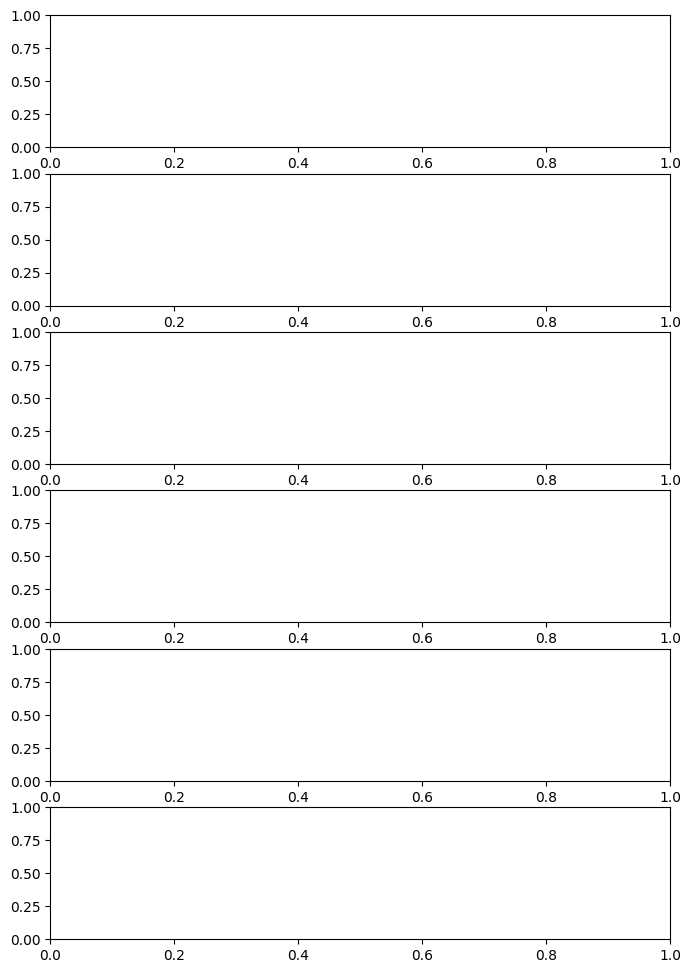

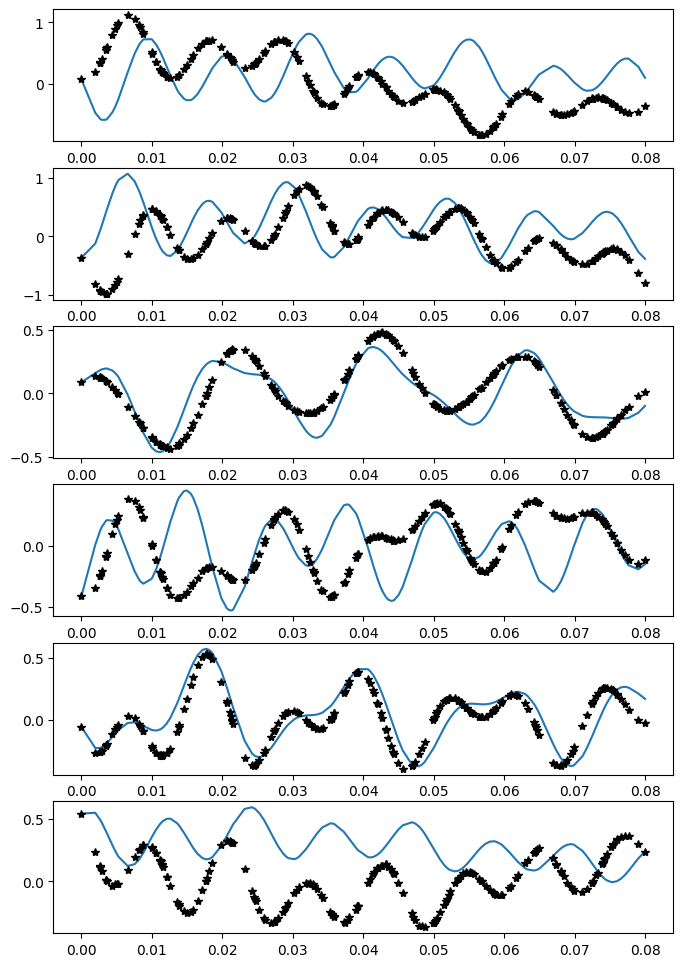

In [93]:
import numpy as np
import random
import time
import opinf

rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
    # model=opinf.models.ContinuousModel(
    #     operators="cAH",
    #     solver=opinf.lstsq.L2Solver(regularizer=1e-4),
    model=JaxCompatibleModel(
        operators='cAH',
        solver=opinf.lstsq.L2Solver(regularizer=1e-2),
    )
).fit(states=snapshots_sampled)

# Solve the ROM over a specified time domain. Make sure it's stable!
Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain)

loaded_operator = np.load("operator.npy")
rom.model._extract_operators(loaded_operator)

# Plot predictions within training time domains
deter_pred = rom.model.predict(
    state0=snapshots_compressed[:, 0], 
    t=time_domain_sampled, 
)
deter_sol = rom.model.predict_result_


fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

for i in range(numPODmodes):
    ax[i].plot(deter_sol.t, deter_sol.y[i])
    ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')

plt.show()

In [94]:
Xs_means = np.stack(
    [gp_samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)],
    axis=0
)
Xs_covs = np.stack(
    [np.cov(gp_samples[f'Xi{i}'].T) for i in range(numPODmodes)],
    axis=0
)

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

In [95]:
# ### Using this operator and our gp we should be able to test this shit out

# plt.clf()
# fig, ax = plt.subplots(numPODmodes)

# O_samples = np.random.normal(loaded_operator, 0.1, size=loaded_operator.shape)
# time = time_m[:, None]
# num_time_steps = time.shape[0]


# f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O_samples.T
# mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)

# for i in range(numPODmodes):
#     lengthscale = Ls_means[i]
#     variance = Vs_means[i]
    
#     Kyy = get_c_phi(lengthscale, variance, time, normalization)

#     Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
#     Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
#     CDashs = get_c_phi_dash(lengthscale, variance, time)
#     DashCs = get_dash_c_phi(lengthscale, variance, time)
#     CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
#     CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
#     # Use Cholesky decomposition for more stable inverse
#     CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
#     A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
#     mu_zi = mu_z[i]
#     gamma = 1e1
#     constraint_cov = A + gamma * jnp.eye(num_time_steps)

#     f_Xi_ohat.T[i]

#     ax[i].plot(time, f_Xi_ohat.T[i], label='f_Ohat')
#     ax[i].plot(time, mu_zi, label='mu_z')

# plt.show()

gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shape: (250,), constraint_cov shape: (250, 250)
gp derivative shape: (250,), f_Xi_ohat shap

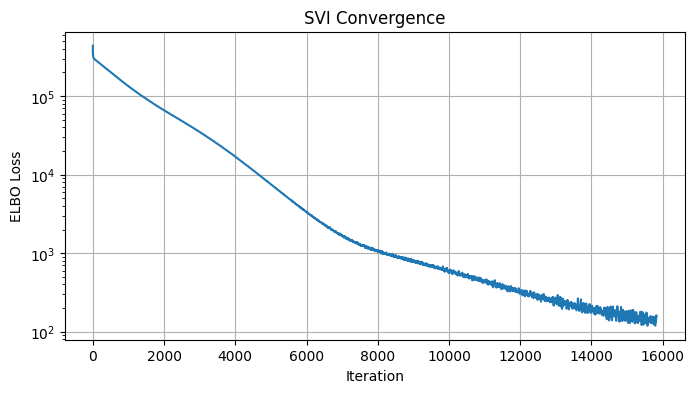

In [96]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()


def model(time, qhat, chi, normalization=1e-6):
    num_time_steps = time.shape[0]

    O_mean = np.random.random(((6, 28)))

    # O = numpyro.sample('O',
    #                 dist.Normal(jnp.zeros_like(O_mean), 1.5**2))
    
    # # Initialize array
    # arr = np.zeros((6, 28))

    # # Fill values
    # arr[:, 0] = 1e1        # value for the 0th element
    # arr[:, 1:6] = 1e3      # values for indices 1–5
    # arr[:, 6:28] = 1e1     # values for indices 6–27

    # O = numpyro.sample('O',
    #                 dist.Normal(jnp.zeros_like(O_mean), arr))

    O = numpyro.sample('O',
                    dist.Normal(loaded_operator, 200/4))

    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        # Priors for hyperparameters
        lengthscale = Ls_means[i]
        Ls.append(lengthscale)

        variance = Vs_means[i]
        Vars.append(variance)

        noise = Ns_means[i]
        noises.append(noise)
        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)

        Xs.append(
            numpyro.sample(
                f"X{i}",
                dist.MultivariateNormal(loc=Xs_means[i], covariance_matrix=Xs_covs[i]+1e-4*jnp.eye(Xs_covs[i].shape[0])),
            )
        )
        
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T

    mu_z, cov_z = joint_gp_derivatives(Ls, Vars, time_domain_sampled, time)
    
    for i in range(numPODmodes):
        # lengthscale = Ls[i]
        # variance = Vars[i]
        # Kyy = Kyys[i]
        # Xi = Xs[i]
        
        # Cache inverse computation
        # Kyy_inv = jnp.linalg.solve(Kyy, jnp.eye(num_time_steps))
        # Kyy_inv = stable_solve(Kyy, jnp.eye(num_time_steps), jitter=normalization)
        # Ds = get_dash_c_phi(lengthscale, variance, time) @ Kyy_inv
        # CDashs = get_c_phi_dash(lengthscale, variance, time)
        # DashCs = get_dash_c_phi(lengthscale, variance, time)
        # CPhis = get_c_phi(lengthscale, variance, time, nugget=normalization)
        # CDoubleDashs = get_c_phi_double_dash(lengthscale, variance, time)
        # Use Cholesky decomposition for more stable inverse
        # CPhis_chol = stable_cholesky(CPhis, jitter=normalization)
        # A = CDoubleDashs - DashCs @ jax.scipy.linalg.cho_solve((CPhis_chol, True), CDashs)
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        gamma = 5e1
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

        print(f"gp derivative shape: {mu_zi.shape}, f_Xi_ohat shape: {f_Xi_ohat.T[i].shape}, constraint_cov shape: {constraint_cov.shape}")
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# You can also use more sophisticated guides like AutoLowRankMultivariateNormal
# guide = autoguide.AutoLowRankMultivariateNormal(model, rank=200)
guide = autoguide.AutoMultivariateNormal(model)
guide = autoguide.AutoDAIS(model)
guide = autoguide.AutoDelta(model)

# Setup optimizer
optimizer = Adam(step_size=0.1)

# Create SVI object
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Initialize
rng_key = jax.random.PRNGKey(42)
svi_state = svi.init(rng_key,
                     time=time_domain_eval_training, 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_eval_training, 
                                  qhat=snapshots_compressed,
                                  chi=noiselevel,
                                  normalization=normalization
                                  )
    return svi_state, loss

# Training loop
num_iterations = 100000  # Adjust as needed
losses = []
patience = 250
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (patience_counter > patience and i > 5000) or (loss < 0):
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gm_samples = predictive(rng_key,
                     time=time_domain_eval_training, 
                     qhat=snapshots_compressed,
                     chi=noiselevel,
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [97]:
# from numpyro.infer import MCMC, NUTS, init_to_value

# Omean = gm_samples['O'].mean(axis=0)
# Ostd = gm_samples['O'].std(axis=0)
# Omean.shape, Ostd.shape

# num_chains = 4

# numpyro.set_host_device_count(num_chains)

# def mcmc_model_with_gamma(time, gamma=5e-2, normalization=1e-6):
#     """MCMC model with adjustable gamma"""
#     num_time_steps = time.shape[0]
    
#     min_relative_std = 0.05  # 10% relative uncertainty
#     min_absolute_std = 1.0  # minimum absolute uncertainty for very small means
#     O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
#     O = numpyro.sample('O', dist.Normal(Omean, O_uncertainty))
    
#     Xs = []
#     for i in range(numPODmodes):
#         X_cov = Xs_covs[i] + normalization*jnp.eye(Xs_covs[i].shape[0])
#         Xs.append(
#             numpyro.sample(
#                 f"X{i}",
#                 dist.MultivariateNormal(loc=Xs_means[i], 
#                                        covariance_matrix=X_cov),
#             )
#         )
    
#     f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
#     mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)
    
#     for i in range(numPODmodes):
#         mu_zi = mu_z[i]
#         cov_zi = cov_z[i]
#         # Use the gamma parameter passed in
#         constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)
        
#         numpyro.sample(
#             f'ode_constraint{i}',
#             dist.MultivariateNormal(mu_zi, constraint_cov),
#             obs=f_Xi_ohat.T[i]
#         )

# # Option 1: Initialize MCMC at MAP values
# # Create initialization dictionary from SVI results
# init_values = {
#     'O': Omean,  # Your MAP estimate for O
# }

# # Add X values from SVI if you have them
# for i in range(numPODmodes):
#     if f'X{i}' in gm_samples:
#         init_values[f'X{i}'] = gm_samples[f'X{i}'].mean(axis=0)
#     else:
#         init_values[f'X{i}'] = Xs_means[i]  # Use prior mean if not available

# # Stage 1: Warm-up with larger gamma
# print("Stage 1: Running with larger gamma for initialization...")
# nuts_kernel_stage1 = NUTS(mcmc_model_with_gamma, 
#                           init_strategy=init_to_value(values=init_values),
#                           dense_mass=True
#                           )
# mcmc_stage1 = MCMC(nuts_kernel_stage1, 
#                    num_warmup=500,
#                    num_samples=1000,
#                    num_chains=num_chains,
#                    chain_method='parallel',
#                    )

# mcmc_stage1.run(rng_key,
#                time=time_domain_eval_training,
#                gamma=1e-1,
#                normalization=normalization,
#                )

# samples = mcmc_stage1.get_samples()

In [107]:
from numpyro.infer import MCMC, NUTS, init_to_value
from numpyro.diagnostics import summary
import jax.numpy as jnp
import numpyro.distributions as dist
import numpyro

# Get initial values from your SVI/guide samples
Omean = gm_samples['O'].mean(axis=0)
Ostd = gm_samples['O'].std(axis=0)
num_chains = 4
numpyro.set_host_device_count(num_chains)

def reparameterized_mcmc_model(time, gamma=5e-2, normalization=1e-6):
    """
    Reparameterized MCMC model using standardized coordinates.
    This reduces correlations between parameters and improves geometry.
    """
    num_time_steps = time.shape[0]
    
    # === REPARAMETERIZE O ===
    # Instead of sampling O directly, sample a standardized version
    # min_relative_std = 0.05
    min_relative_std = 0.1
    min_absolute_std = 1.0
    O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
    
    # Sample standardized O (zero mean, unit variance)
    O_standardized = numpyro.sample('O_standardized', 
                                    dist.Normal(jnp.zeros_like(Omean), 
                                               jnp.ones_like(Omean)))
    
    # Deterministically transform to actual O
    # This makes O = Omean + O_uncertainty * O_standardized
    O = numpyro.deterministic('O', Omean + O_uncertainty * O_standardized)
    
    # === REPARAMETERIZE X VARIABLES ===
    Xs = []
    Xs_standardized = []
    for i in range(numPODmodes):
        # Compute Cholesky decomposition for numerical stability
        X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
        
        # Use Cholesky factorization for more stable sampling
        try:
            L = jnp.linalg.cholesky(X_cov)
        except:
            # If Cholesky fails, add more regularization
            X_cov = Xs_covs[i] + (normalization * 10) * jnp.eye(Xs_covs[i].shape[0])
            L = jnp.linalg.cholesky(X_cov)
        
        # Sample standardized X (zero mean, unit variance)
        X_std = numpyro.sample(
            f"X{i}_standardized",
            dist.Normal(jnp.zeros_like(Xs_means[i]), jnp.ones_like(Xs_means[i]))
        )
        Xs_standardized.append(X_std)
        
        # Transform to actual X using Cholesky factor
        X = numpyro.deterministic(f"X{i}", Xs_means[i] + L @ X_std)
        Xs.append(X)
    
    # === MODEL LIKELIHOOD (unchanged) ===
    f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
    mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)
    
    for i in range(numPODmodes):
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)
        
        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat.T[i]
        )

# === INITIALIZE WITH GOOD VALUES ===
# Convert your MAP estimates to standardized space for initialization
init_values_standardized = {
    'O_standardized': jnp.zeros_like(Omean),  # Start at the mean
}

# # Initialize X in standardized space
# for i in range(numPODmodes):
#     if f'X{i}' in gm_samples:
#         # If you have samples, convert them to standardized space
#         X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
#         try:
#             L = jnp.linalg.cholesky(X_cov)
#             L_inv = jnp.linalg.inv(L)
#             X_centered = gm_samples[f'X{i}'].mean(axis=0) - Xs_means[i]
#             init_values_standardized[f'X{i}_standardized'] = L_inv @ X_centered
#         except:
#             init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])
#     else:
#         init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])

# === CONFIGURE STRUCTURED MASS MATRIX ===
# Group correlated parameters together
dense_mass_blocks = [
    ("O_standardized",),  # O parameters are correlated within themselves
    tuple([f"X{i}_standardized" for i in range(numPODmodes)])  # X parameters likely correlated
]

# === RUN MCMC WITH IMPROVED SETTINGS ===
print("Running MCMC with reparameterized model...")
nuts_kernel = NUTS(
    reparameterized_mcmc_model,
    init_strategy=init_to_value(values=init_values_standardized),
    # dense_mass=dense_mass_blocks,  # Use structured mass matrix
    # max_tree_depth=12,  # Increase from default 10
    # target_accept_prob=0.9,  # Increase for better exploration in difficult geometries
)

mcmc = MCMC(
    nuts_kernel,
    num_warmup=150,  # Increase warm-up for better adaptation
    num_samples=200,
    num_chains=num_chains,
    chain_method='parallel',
    progress_bar=True,
)

# Run with moderate gamma first
mcmc.run(
    rng_key,
    time=time_domain_eval_training,
    gamma=1e0,  # You can adjust this
    normalization=normalization,
)


# from numpyro.infer import MCMC, NUTS, init_to_value
# from numpyro.diagnostics import summary
# import jax.numpy as jnp
# import numpyro.distributions as dist
# import numpyro

# # Get initial values from your SVI/guide samples
# Omean = gm_samples['O'].mean(axis=0)
# Ostd = gm_samples['O'].std(axis=0)
# num_chains = 4
# numpyro.set_host_device_count(num_chains)

# def stable_mcmc_model(time, gamma=5e-2, normalization=1e-6):
#     """
#     Numerically stable MCMC model with better conditioning
#     """
#     num_time_steps = time.shape[0]
    
#     # === SAMPLE O WITH BETTER SCALING ===
#     min_relative_std = 0.1  # Increased from 0.05 for better conditioning
#     min_absolute_std = 1.0
#     O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
    
#     # Add small regularization to prevent numerical issues
#     O_uncertainty = O_uncertainty + 1e-6
    
#     # Sample O directly with proper scaling
#     O = numpyro.sample('O', dist.Normal(Omean, O_uncertainty))
    
#     # === SAMPLE X WITH DIAGONAL COVARIANCE (for stability) ===
#     Xs = []
#     for i in range(numPODmodes):
#         # Start with diagonal approximation for numerical stability
#         # Extract diagonal of covariance and add regularization
#         X_cov_diag = jnp.diag(Xs_covs[i]) + normalization
#         X_cov_diag = jnp.maximum(X_cov_diag, 1e-4)  # Ensure minimum variance
        
#         # Use diagonal covariance for more stable sampling
#         X = numpyro.sample(
#             f"X{i}",
#             dist.Normal(Xs_means[i], jnp.sqrt(X_cov_diag))
#         )
#         Xs.append(X)
    
#     # === COMPUTE LIKELIHOOD WITH NUMERICAL STABILITY ===
#     f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
    
#     # Clip to prevent numerical overflow
#     f_Xi_ohat = jnp.clip(f_Xi_ohat, -1e6, 1e6)
    
#     mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)
    
#     for i in range(numPODmodes):
#         mu_zi = jnp.clip(mu_z[i], -1e6, 1e6)  # Clip mean
#         cov_zi = cov_z[i]
        
#         # Add significant regularization for numerical stability
#         # Start with larger gamma for stability
#         constraint_cov_diag = jnp.diag(cov_zi) + gamma
#         constraint_cov_diag = jnp.maximum(constraint_cov_diag, 1e-3)  # Ensure minimum variance
        
#         # Use diagonal covariance for stability
#         numpyro.sample(
#             f'ode_constraint{i}',
#             dist.Normal(mu_zi, jnp.sqrt(constraint_cov_diag)),
#             obs=f_Xi_ohat.T[i]
#         )

# # === SIMPLER INITIALIZATION ===
# init_values = {}
# init_values['O'] = Omean  # Start at the mean


# for i in range(numPODmodes):
#     if f'X{i}' in gm_samples:
#         init_values[f'X{i}'] = gm_samples[f'X{i}'].mean(axis=0)
#     else:
#         init_values[f'X{i}'] = Xs_means[i]

# # === START WITH SIMPLER SAMPLER CONFIGURATION ===
# print("Running MCMC with stabilized model...")

# # First, try with diagonal mass matrix and lower tree depth
# nuts_kernel = NUTS(
#     stable_mcmc_model,
#     init_strategy=init_to_value(values=init_values),
#     dense_mass=False,  # Start with diagonal for stability
#     max_tree_depth=12,  # Lower tree depth initially
#     target_accept_prob=0.8,  # Standard target
#     # step_size=1e-3,  # Explicitly set initial step size
# )

# mcmc = MCMC(
#     nuts_kernel,
#     num_warmup=1000,
#     num_samples=1000,
#     num_chains=num_chains,
#     chain_method='parallel',
#     progress_bar=True,
# )

# # Run with larger gamma for numerical stability
# rng_key = jax.random.PRNGKey(0)  # Make sure rng_key is defined
# mcmc.run(
#     rng_key,
#     time=time_domain_eval_training,
#     gamma=1e-1,  # Larger gamma for stability
#     normalization=1e-3,  # Larger normalization
# )

Running MCMC with reparameterized model...


sample: 100%|██████████| 350/350 [00:44<00:00,  7.81it/s, 255 steps of size 2.77e-02. acc. prob=0.89] 


In [108]:
# === CHECK DIAGNOSTICS ===
def print_diagnostics(mcmc):
    """Print detailed diagnostics for each parameter"""
    samples = mcmc.get_samples(group_by_chain=True)
    summary_dict = summary(samples)
    
    print("\n" + "="*60)
    print("MCMC Diagnostics Summary")
    print("="*60)
    
    # Separate standardized and deterministic variables
    standardized_params = []
    deterministic_params = []
    constraint_params = []
    
    for param in summary_dict.keys():
        if '_standardized' in param:
            standardized_params.append(param)
        elif 'ode_constraint' in param:
            constraint_params.append(param)
        else:
            deterministic_params.append(param)
    
    # Print standardized parameters (these are what we actually sample)
    if standardized_params:
        print("\n📊 Standardized Parameters (key for convergence):")
        print("-" * 50)
        for param in sorted(standardized_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            min_ess = jnp.min(stats["n_eff"])
            
            if max_rhat > 1.01:
                status = "⚠️ "
            else:
                status = "✅"
            
            print(f"{status} {param:30s} r_hat={max_rhat:.4f}, min_ESS={min_ess:.0f}")
    
    # Print deterministic transformations
    if deterministic_params:
        print("\n📈 Transformed Parameters:")
        print("-" * 50)
        for param in sorted(deterministic_params):
            stats = summary_dict[param]
            max_rhat = jnp.max(stats["r_hat"])
            print(f"   {param:30s} r_hat={max_rhat:.4f}")
    
    # Check for problems
    problem_params = [p for p, s in summary_dict.items() 
                     if jnp.max(s["r_hat"]) > 1.01 and '_standardized' in p]
    
    if problem_params:
        print(f"\n⚠️  Warning: {len(problem_params)} parameters have r_hat > 1.01")
        print("Consider:")
        print("  1. Increasing num_warmup and num_samples")
        print("  2. Adjusting gamma (try values between 1e-2 and 1e-1)")
        print("  3. Checking if normalization needs adjustment")
    else:
        print("\n✅ All parameters have converged well (r_hat ≤ 1.01)")
    
    return summary_dict

# Print diagnostics
diagnostics = print_diagnostics(mcmc)

# Get the final samples
samples = mcmc.get_samples()
print(f"\nSampling complete. Retrieved {len(samples['O'])} samples.")


MCMC Diagnostics Summary

📊 Standardized Parameters (key for convergence):
--------------------------------------------------
⚠️  O_standardized                 r_hat=1.0890, min_ESS=34
✅ X0_standardized                r_hat=1.0098, min_ESS=547
✅ X1_standardized                r_hat=1.0096, min_ESS=502
⚠️  X2_standardized                r_hat=1.0188, min_ESS=226
⚠️  X3_standardized                r_hat=1.0225, min_ESS=201
⚠️  X4_standardized                r_hat=1.0596, min_ESS=56
⚠️  X5_standardized                r_hat=1.0259, min_ESS=91

📈 Transformed Parameters:
--------------------------------------------------
   O                              r_hat=1.0890
   X0                             r_hat=1.0098
   X1                             r_hat=1.0096
   X2                             r_hat=1.0188
   X3                             r_hat=1.0225
   X4                             r_hat=1.0596
   X5                             r_hat=1.0259

⚠️  Warning: 5 parameters have r_hat > 1.01
C

In [109]:
from numpyro.diagnostics import summary

summary_dict = summary(mcmc.get_samples(), group_by_chain=False)

# print the largest r_hat for each variable
for k, v in summary_dict.items():
    spaces = " " * max(12 - len(k), 0)
    print("[{}] {} \t max r_hat: {:.4f}".format(k, spaces, np.max(v["r_hat"])))

[O]             	 max r_hat: 1.0268
[O_standardized]  	 max r_hat: 1.0268
[X0]            	 max r_hat: 1.0131
[X0_standardized]  	 max r_hat: 1.0131
[X1]            	 max r_hat: 1.0085
[X1_standardized]  	 max r_hat: 1.0085
[X2]            	 max r_hat: 1.0080
[X2_standardized]  	 max r_hat: 1.0080
[X3]            	 max r_hat: 1.0173
[X3_standardized]  	 max r_hat: 1.0173
[X4]            	 max r_hat: 1.0467
[X4_standardized]  	 max r_hat: 1.0468
[X5]            	 max r_hat: 1.0073
[X5_standardized]  	 max r_hat: 1.0073


### Generate Predictions, Means, Medians and Percentiles via samples

In [110]:
Os = []
Xs = []
rom_solves = []

for i in range(num_pulls):
    O = samples['O'][i]
    Os.append(O)
    Xs.append(np.array([samples[f'X{j}'][i] for j in range(numPODmodes)]))

    rom.model._extract_operators(np.array(O))
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_domain_eval_training)
    if rom.model.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print("Bad solve, skipping", rom.model.predict_result_.y.shape)
        continue
    rom_solves.append(rom.model.predict_result_.y)


Xs = np.array(Xs)
Os = np.array(Os)
rom_solves = np.array(rom_solves)


X_mean = Xs.mean(axis=0)
O_mean = Os.mean(axis=0)
rom_solves_mean = rom_solves.mean(axis=0)
X_median = np.median(Xs, axis=0)
O_median = np.median(Os, axis=0)
rom_solves_median = np.median(rom_solves, axis=0)
rom_solves_95 = np.percentile(rom_solves, 99, axis=0)
rom_solves_5 = np.percentile(rom_solves, 1, axis=0)
X_mean.shape, O_mean.shape, X_median.shape, O_median.shape, rom_solves_5.shape

Bad solve, skipping (6, 106)
Bad solve, skipping (6, 96)
Bad solve, skipping (6, 100)
Bad solve, skipping (6, 111)
Bad solve, skipping (6, 98)
Bad solve, skipping (6, 100)
Bad solve, skipping (6, 115)
Bad solve, skipping (6, 108)
Bad solve, skipping (6, 115)
Bad solve, skipping (6, 114)
Bad solve, skipping (6, 151)
Bad solve, skipping (6, 94)
Bad solve, skipping (6, 112)
Bad solve, skipping (6, 134)
Bad solve, skipping (6, 132)
Bad solve, skipping (6, 152)
Bad solve, skipping (6, 127)
Bad solve, skipping (6, 149)
Bad solve, skipping (6, 106)
Bad solve, skipping (6, 217)
Bad solve, skipping (6, 182)
Bad solve, skipping (6, 121)
Bad solve, skipping (6, 121)
Bad solve, skipping (6, 186)
Bad solve, skipping (6, 159)
Bad solve, skipping (6, 115)
Bad solve, skipping (6, 115)
Bad solve, skipping (6, 135)
Bad solve, skipping (6, 106)
Bad solve, skipping (6, 116)
Bad solve, skipping (6, 138)
Bad solve, skipping (6, 101)
Bad solve, skipping (6, 107)
Bad solve, skipping (6, 108)
Bad solve, skippi

((6, 250), (6, 28), (6, 250), (6, 28), (6, 250))

In [111]:
# ### Check Xs

# plt.clf()
# fig, ax = plt.subplots(numPODmodes,1, figsize = (8, 12))

# for i in range(numPODmodes):
#     for j in range(Xs.shape[0]):
#         ax[i].plot(time_m, Xs[j, i], color='gray', alpha=0.3)
#     ax[i].plot(time_m, X_mean[i], color='blue', label='Mean', linewidth=2)
#     ax[i].plot(time_m, X_median[i], color='red', label='Median', linewidth=2)
#     ax[i].scatter(time_domain_sampled, snapshots_compressed[i], color='black', label='Data Points', zorder=5)
#     ax[i].set_title(f'Latent State X[{i}]')
#     ax[i].legend()
# plt.suptitle("Inferred Latent States X")
# plt.tight_layout()
# plt.show()

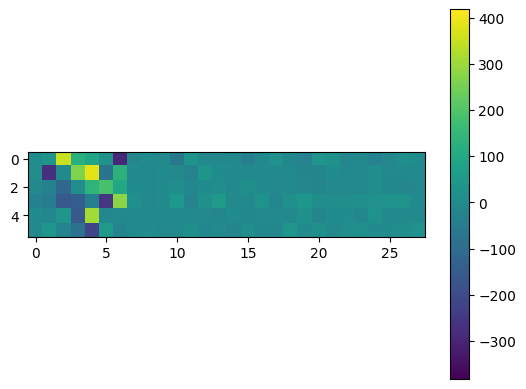

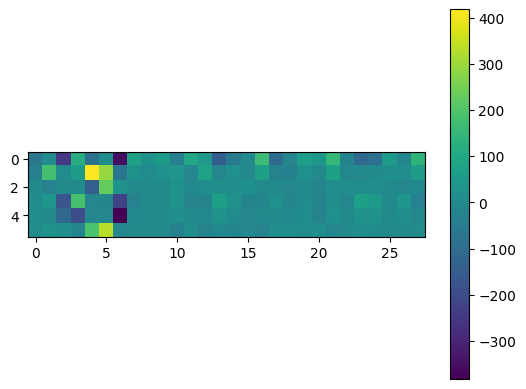

In [112]:
plt.imshow(loaded_operator, vmin = min(loaded_operator.min(), O_mean.min()), vmax = max(loaded_operator.max(), O_mean.max()))
plt.colorbar()
plt.show()
plt.imshow(O_mean, vmin = min(O_mean.min(), loaded_operator.min()), vmax = max(O_mean.max(), loaded_operator.max()))
plt.colorbar()
plt.show()

In [113]:
# plt.clf()
# fig, ax = plt.subplots(numPODmodes, figsize=(12,8))

# for i in range(numPODmodes):
#     ax[i].plot(time_m, X_mean[i])
#     ax[i].plot(time_m, rom_solves_median[i], linestyle='--')
#     ax[i].plot(time_m, rom_solves_mean[i], linestyle=':')
#     ax[i].plot(time_domain_sampled, snapshots_compressed[i], 'k*')
#     ax[i].fill_between(time_m, rom_solves_5[i,:], rom_solves_95[i, :], color='gray', alpha=0.3)



# plt.show()

(800, 6, 28) (800, 6, 250)
Bad solve within training domain, skipping (6, 106)
Bad solve within training domain, skipping (6, 96)
Bad solve within training domain, skipping (6, 100)
Bad solve within prediction domain, skipping (6, 349)
Bad solve within prediction domain, skipping (6, 368)
Bad solve within prediction domain, skipping (6, 366)
Bad solve within training domain, skipping (6, 111)
Bad solve within training domain, skipping (6, 98)
Bad solve within training domain, skipping (6, 100)
Bad solve within prediction domain, skipping (6, 359)
Bad solve within training domain, skipping (6, 115)
Bad solve within training domain, skipping (6, 108)
Bad solve within prediction domain, skipping (6, 345)
Bad solve within training domain, skipping (6, 115)
Bad solve within prediction domain, skipping (6, 338)
Bad solve within training domain, skipping (6, 114)
Bad solve within prediction domain, skipping (6, 333)
Bad solve within training domain, skipping (6, 151)
Bad solve within predicti

<Figure size 640x480 with 0 Axes>

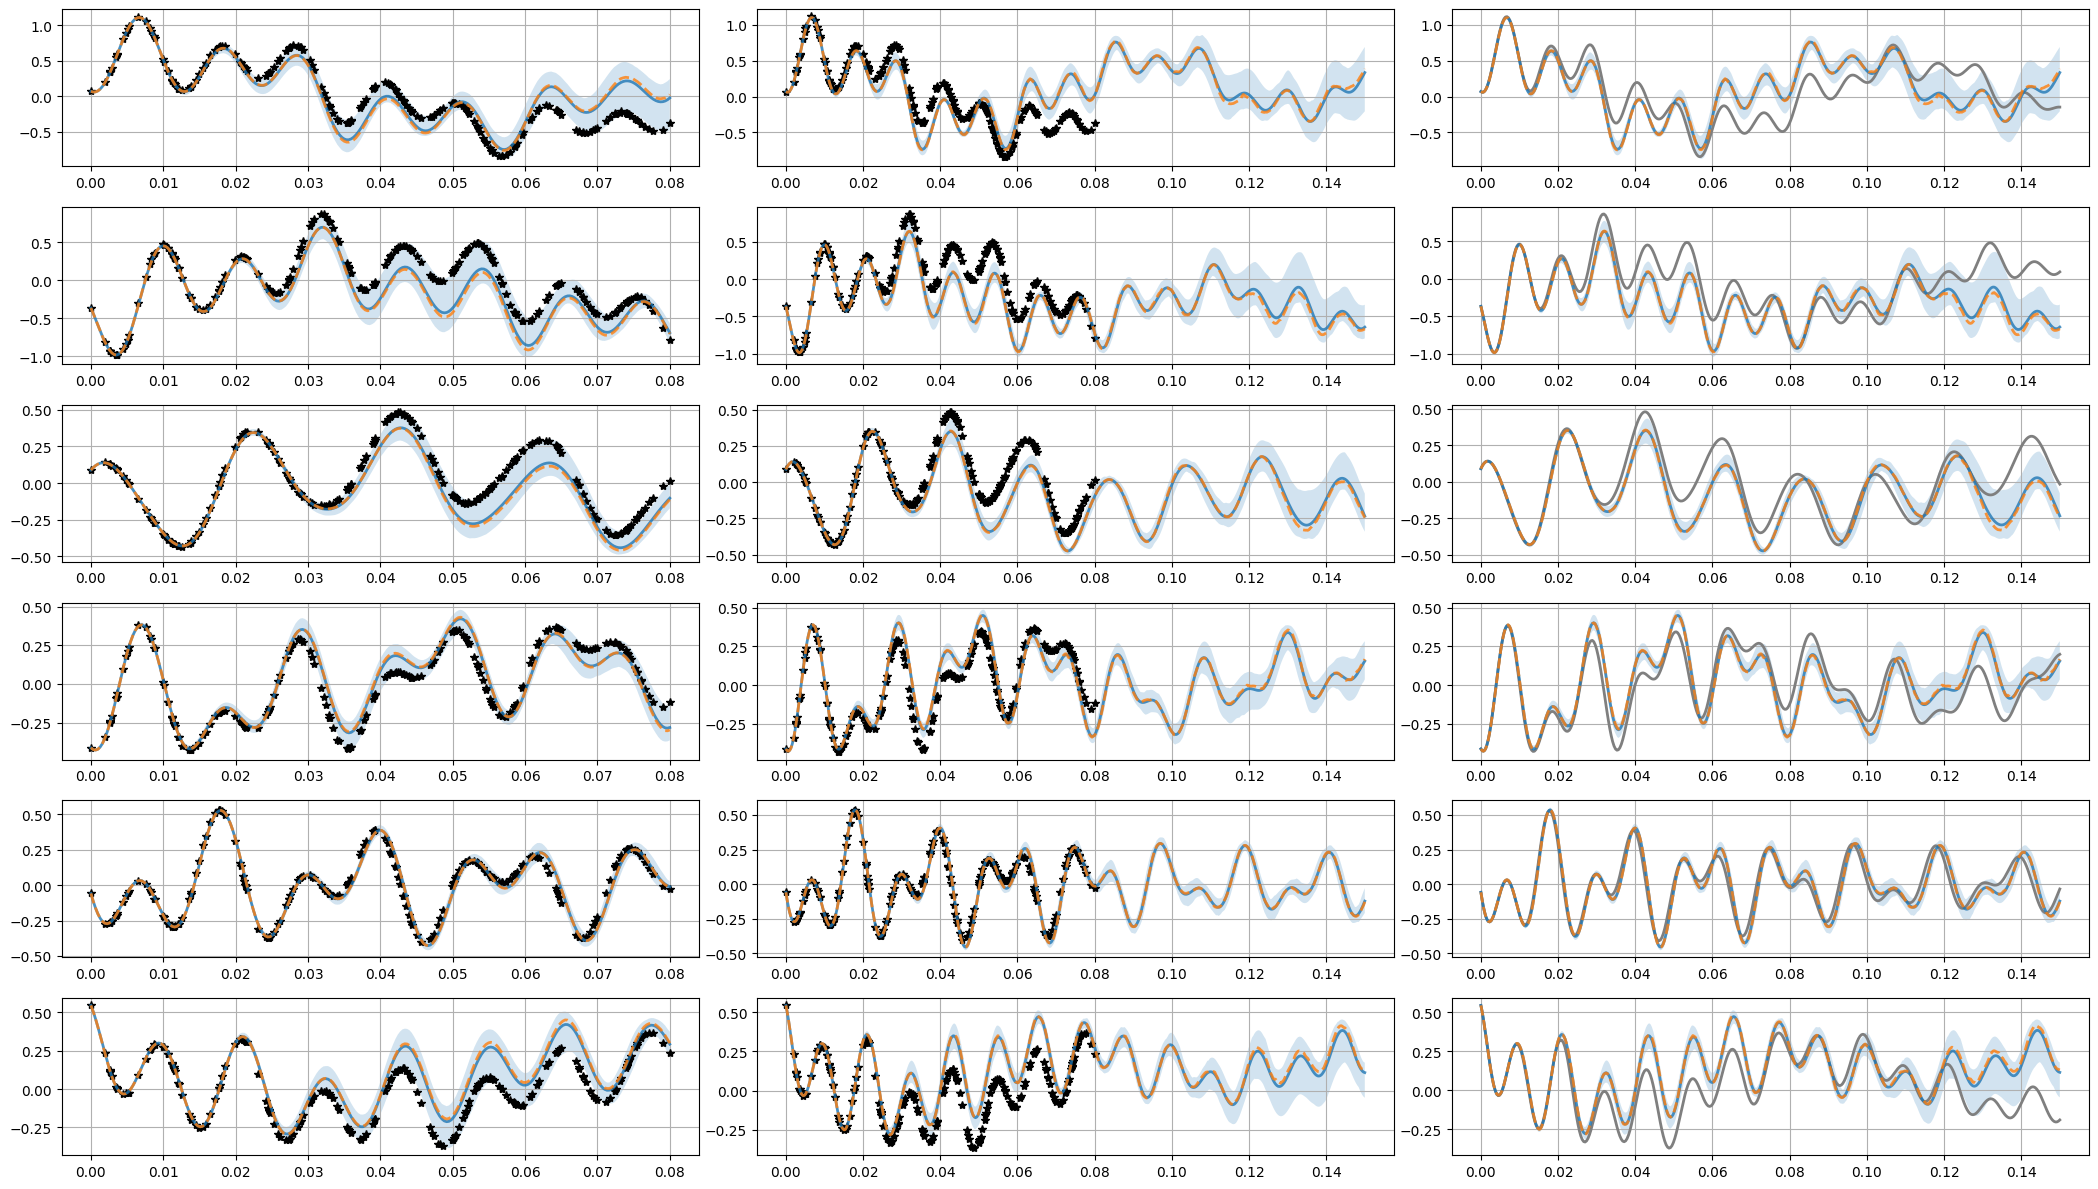

In [114]:
# Plot posterior samples
import euler_plotter
import importlib
importlib.reload(euler_plotter)

plotter = euler_plotter.EulerPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plt.clf()
plotter.operator_plot(
                    operator_samples=samples['O'],
                    latent_state_samples=[samples[f'X{i}'] for i in range(numPODmodes)],
                    rom=rom,
                    figsize=(21, 12),
                    max_num_samples=1000
)